# Classification with PyTorch

## 1. Import the packages

In [1]:
import torch 
import torch.nn as nn

In [30]:
from torchinfo import summary

In [35]:
import torch.optim as optim

In [2]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [3]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

## 2. Getting the data

We are going to consider a toy dataset: small enough to play with it and explore but still rich enough to learn something

In [5]:
N_SAMPLES = 1000
data_raw = make_circles(n_samples=N_SAMPLES, noise=0.03, random_state=42)

In [6]:
X, y = data_raw
len(X), len(y)

(1000, 1000)

In [7]:
X[:5],y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

We have two features in `X` and we have two values for `y` so we can say that this is a **binary classification** problem

## 3. Device agnostic

In [39]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

## 4. Visualize the data

In [9]:
df = pd.DataFrame({"X1":X[:,0], "X2":X[:,1], "y":y})
df.head()

,X1,X2,y
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


<Figure size 1200x800 with 0 Axes>

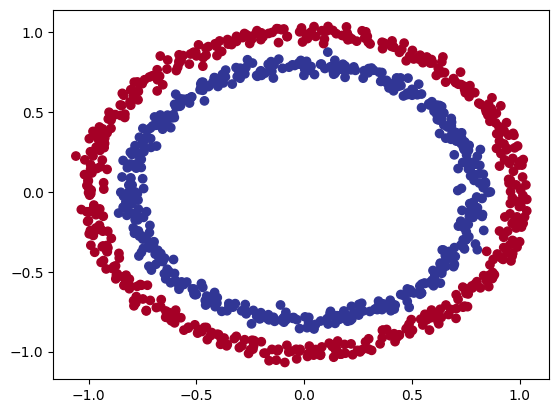

In [10]:
plt.figure(figsize=(12,8))
_, ax = plt.subplots()
ax.scatter(df.X1, df.X2, c=df.y, cmap=plt.cm.RdYlBu)
plt.show();

## 5. Splitting the data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

<Figure size 1200x800 with 0 Axes>

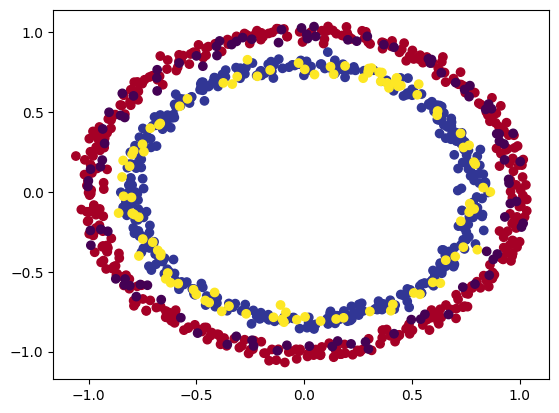

In [13]:
plt.figure(figsize=(12,8))
_, ax = plt.subplots()
ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap=plt.cm.RdYlBu)
ax.scatter(X_test[:,0], X_test[:,1], c=y_test)
plt.show();

## 6. Convert the data into tensors

Note: there is a difference between

- `torch.Tensor()`
- `torch.from_numpy()`

the first one creates a new copy and is indepedent from the original array whereas the second is tight to the original array (creates a view so it shares memory $\Longrightarrow$ more efficient)

use the second when we do not need to compute gradients for instance

In [167]:

X_train_ten = torch.tensor(X_train, dtype=torch.float32)# No need for gradient tracking for train set
y_train_ten = torch.tensor(y_train, dtype=torch.float32)# No need for gradient tracking for train set
X_test_ten = torch.tensor(X_test, dtype=torch.float32) # No need for gradient tracking for test set
y_test_ten = torch.tensor(y_test, dtype=torch.float32) # No need for gradient tracking for test set

In [168]:
def set_to_device(item):
    return item.to(device)

In [169]:
X_train_ten = set_to_device(X_train_ten)
y_train_ten = set_to_device(y_train_ten)
X_test_ten = set_to_device(X_test_ten)
y_test_ten = set_to_device(y_test_ten)
X_train_ten

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]], device='mps:0')

In [170]:
X_train_ten.shape, y_train_ten.shape, X_test_ten.shape, y_test_ten.shape

(torch.Size([800, 2]),
 torch.Size([800]),
 torch.Size([200, 2]),
 torch.Size([200]))

In [171]:
X_train_ten.ndim, y_train_ten.ndim, X_test_ten.ndim, y_test_ten.ndim

(2, 1, 2, 1)

## 7. Building a Neural Network classification Model

In [172]:
torch.manual_seed(42)

In [173]:
class FirstClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.Linear1 = nn.Linear(in_features=2, out_features=128)
        self.relu1 = nn.ReLU()
        self.Linear2 = nn.Linear(in_features=128, out_features=64)
        self.relu2 = nn.ReLU()
        self.Linear3 = nn.Linear(in_features=64, out_features=1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        x = self.Linear1(inputs)
        x = self.relu1(x)
        x = self.Linear2(x)
        x = self.relu2(x)
        x = self.Linear3(x)
        x = self.sigmoid(x)
        return x


In [174]:
class ClassificationModel(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.network = nn.Sequential(
            nn.Linear(in_features=2, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=1),
            nn.Sigmoid()
        )

    def forward(self, inputs:torch.Tensor) -> torch.Tensor:
        return self.network(inputs)


In [175]:
model1 = FirstClassificationModel()
model1 = set_to_device(model1)

In [176]:
model1_1 = ClassificationModel()
model1_1 = set_to_device(model1_1)

In [177]:
display(summary(model1))
display(summary(model1_1))

Layer (type:depth-idx)                   Param #
FirstClassificationModel                 --
├─Linear: 1-1                            384
├─ReLU: 1-2                              --
├─Linear: 1-3                            8,256
├─ReLU: 1-4                              --
├─Linear: 1-5                            65
├─Sigmoid: 1-6                           --
Total params: 8,705
Trainable params: 8,705
Non-trainable params: 0

Layer (type:depth-idx)                   Param #
ClassificationModel                      --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       384
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       8,256
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       65
│    └─Sigmoid: 2-6                      --
Total params: 8,705
Trainable params: 8,705
Non-trainable params: 0

## 8. Training the model

In [178]:
optimizer = optim.Adam(lr=0.01, params=model1_1.parameters()) # linking the parameters of the model to the optimizer
criterion = nn.BCELoss()

In [121]:
def accuracy_fn(y_preds:torch.Tensor, y_true:torch.Tensor) -> float:
    y_preds_classes = y_preds.argmax(dim=1)
    correct = torch.eq(y_preds_classes, y_true).sum().item()
    acc = (correct/len(y_preds))*100
    return acc

In [179]:
epochs = 500
losses_train = []
losses_test= []
for epoch in range(epochs):
    model1.train() # set the training mode
    preds = model1_1(X_train_ten) # make a prediction
    loss_train = criterion(preds.squeeze(), y_train_ten) # compute the loss

    optimizer.zero_grad() # set the gradient to 0
    loss_train.backward() # perform backpropagation
    optimizer.step()

    # evaluate the trainig
    model1.eval() # set the eval mode for the model
    with torch.inference_mode():
        preds_test = model1_1(X_test_ten)
        loss_test = criterion(preds_test.squeeze(), y_test_ten)
    
    losses_train.append(loss_train)
    losses_test.append(loss_test)

    test_acc = accuracy_fn(preds_test, y_test_ten)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Loss-train:{loss_train} | Loss-test: {loss_test} | test acc.: {test_acc:.2f}")

Epoch: 0 | Loss-train:0.6940749883651733 | Loss-test: 0.6927956342697144 | test acc.: 50.00
Epoch: 20 | Loss-train:0.17571388185024261 | Loss-test: 0.18098148703575134 | test acc.: 50.00
Epoch: 40 | Loss-train:0.008042600937187672 | Loss-test: 0.018711082637310028 | test acc.: 50.00
Epoch: 60 | Loss-train:0.002504823263734579 | Loss-test: 0.008934546262025833 | test acc.: 50.00
Epoch: 80 | Loss-train:0.0015515952836722136 | Loss-test: 0.00689623411744833 | test acc.: 50.00
Epoch: 100 | Loss-train:0.0010598888620734215 | Loss-test: 0.0054440428502857685 | test acc.: 50.00
Epoch: 120 | Loss-train:0.0007200288819149137 | Loss-test: 0.004428870975971222 | test acc.: 50.00
Epoch: 140 | Loss-train:0.0004942470695823431 | Loss-test: 0.003564013633877039 | test acc.: 50.00
Epoch: 160 | Loss-train:0.00034122311626560986 | Loss-test: 0.002927336608991027 | test acc.: 50.00
Epoch: 180 | Loss-train:0.0002486925513949245 | Loss-test: 0.0025005550123751163 | test acc.: 50.00
Epoch: 200 | Loss-train:

In [180]:
def plot_losses(train_loss: list[float], test_loss: list[float]) -> None:
    _, ax = plt.subplots()
    ax.plot(range(0,len(train_loss)), train_loss, color="#155F82", label="Train loss")
    ax.plot(range(0,len(test_loss)), test_loss, color="#823915", label="Test loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Binary Cross Entropy")
    ax.legend()
    plt.show()

In [181]:
losses_train = [item.detach().cpu().numpy() for item in losses_train]
losses_test = [item.detach().cpu().numpy() for item in losses_test]

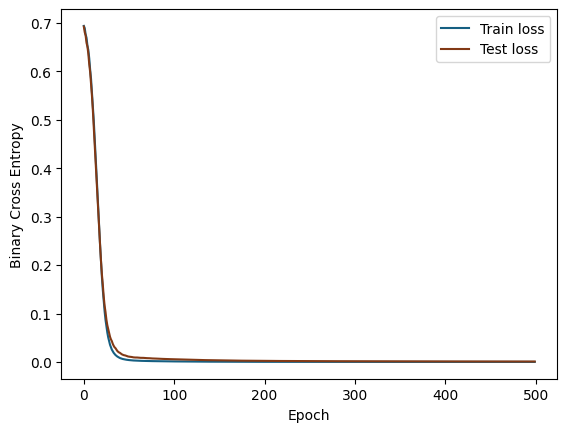

In [182]:
plot_losses(losses_train, losses_test)

## 9. Visualizing the data (prediction onto the dataset)

In [183]:
import requests
from pathlib import Path

In [184]:
try:
    response = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
except:
    print("Error while fetching the data")

In [185]:
if Path("helper_function.py").is_file():
    print("File already there !")
else:
    with open("helper_function.py", mode="wb") as file: # note the response is in binary format
        file.write(response.content)

File already there !


In [186]:
import importlib
import helper_function

In [187]:
importlib.reload(helper_function)

<module 'helper_function' from '/Users/maximecollet/Desktop/PyTorch/ZTM_nb/Learning_PyTorch/helper_function.py'>

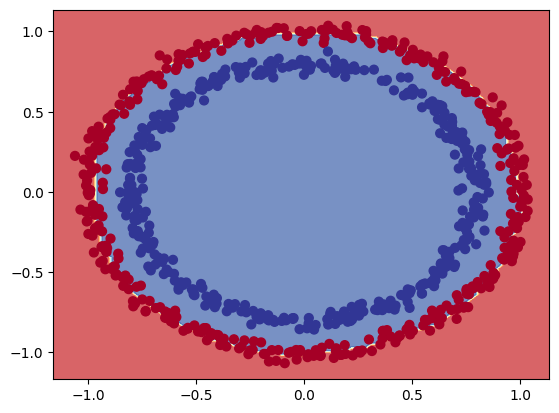

In [188]:
helper_function.plot_decision_boundary(model=model1_1, X=X_train_ten, y=y_train_ten)

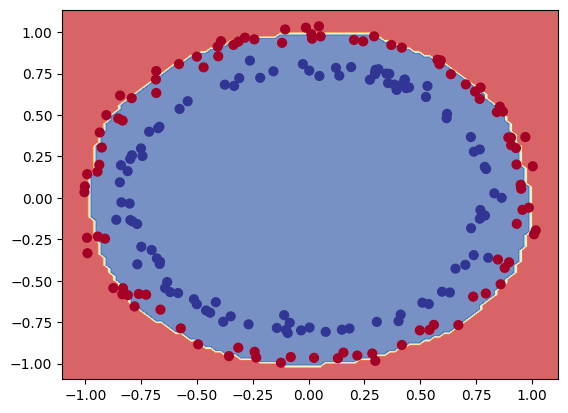

In [189]:
helper_function.plot_decision_boundary(model=model1_1, X=X_test_ten, y=y_test_ten)